In [1]:
pip install tensorflow opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
import os
import cv2
import imghdr
from matplotlib import pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ( 
    Conv2D, MaxPooling2D, Dense,
    Flatten, Dropout, BatchNormalization,
    RandomFlip, RandomRotation, RandomZoom, RandomContrast, Rescaling
)
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.preprocessing import image
import random

In [1]:
# - load ảnh
# - tiền xử lý ảnh
# - chia ảnh thành các batch
# - chia các batch thành các tập train/val/test
# - tạo mô hình
# - train mô hình bằng tập train cùng với tập val
# - thử nghiệm bằng tập test

data_dir = "C:\\Users\\nguye\\Downloads\\dataset_augumented"

data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(224, 224),        # <--- Resize về 255x255
    batch_size=8,
    label_mode='categorical'      # <--- Quan trọng: 22 class → dùng categorical
)
# Kiểm tra class names
class_names = data.class_names
print(f"Classes: {class_names}")
print(f"Số class: {len(class_names)}")  # Phải = 22

# -------------------------------
# 2. Chuẩn hóa ảnh (0-1)
# -------------------------------
data = data.map(lambda x, y: (x / 255.0, y))

# -------------------------------
# 3. Chia train/val/test theo batch 
# -------------------------------
total_batches = len(data)
train_size = int(total_batches * 0.7)
val_size = int(total_batches * 0.2)
test_size = total_batches - train_size - val_size  

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size)

print(f"Batches: Train={train_size}, Val={val_size}, Test={test_size}")

# -------------------------------
# 4. Xây dựng model
# -------------------------------
model = Sequential([
    # Block 1
    Conv2D(64, (3,3), padding='same', activation='relu', input_shape=(224, 224, 3)),
    Conv2D(64, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2), strides=2),

    # Block 2
    Conv2D(128, (3,3), padding='same', activation='relu'),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2), strides=2),

    # Block 3
    Conv2D(256, (3,3), padding='same', activation='relu'),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2), strides=2),

    # Block 4
    Conv2D(512, (3,3), padding='same', activation='relu'),
    Conv2D(512, (3,3), padding='same', activation='relu'),
    Conv2D(512, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2), strides=2),

    # Block 5
    Conv2D(512, (3,3), padding='same', activation='relu'),
    Conv2D(512, (3,3), padding='same', activation='relu'),
    Conv2D(512, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2), strides=2),

    # Classifier
    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    # Dropout(0.5),
    Dense(len(class_names), activation='softmax')  # 22 class
])
# -------------------------------
# 5. Compile đúng cho multi-class
# -------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

# -------------------------------
# 6. Callback TensorBoard
# -------------------------------
logdir = 'logs'
tensorboard_callback = TensorBoard(log_dir=logdir)

# -------------------------------
# 7. Train
# -------------------------------
hist = model.fit(
    train,
    epochs=10,
    validation_data=val,
    callbacks=[tensorboard_callback]
)

# -------------------------------
# 8. Đánh giá trên test
# -------------------------------
test_loss, test_acc = model.evaluate(test)
print(f"Test accuracy: {test_acc:.4f}")

model.save("C:\\Users\\nguye\\Downloads\\trained_10.h5")

NameError: name 'tf' is not defined

In [5]:
hist.history

{'loss': [19.611679077148438,
  13.556350708007812,
  7.531802654266357,
  6.120185852050781,
  4.3643035888671875,
  2.986609935760498,
  2.4948322772979736,
  2.419090747833252,
  2.1189470291137695,
  1.937713861465454,
  2.126877546310425,
  1.9222681522369385,
  1.9251121282577515,
  1.8426320552825928,
  1.7664729356765747,
  1.639920711517334,
  1.7708603143692017,
  1.7799307107925415,
  1.6017860174179077,
  1.5406477451324463,
  1.558097004890442,
  1.5327396392822266,
  1.5143548250198364,
  1.6306488513946533,
  1.5947487354278564,
  1.666197657585144,
  1.2725578546524048,
  1.3812568187713623,
  1.3279026746749878,
  1.295148491859436,
  1.2096881866455078,
  1.1981325149536133,
  1.2703664302825928,
  1.296939730644226,
  1.2708559036254883,
  1.3821710348129272,
  1.558547019958496,
  1.465021014213562,
  1.340598464012146,
  1.230910301208496,
  1.324683427810669,
  1.4691507816314697,
  1.9466203451156616,
  1.4841569662094116,
  1.5211538076400757,
  1.41951167583465

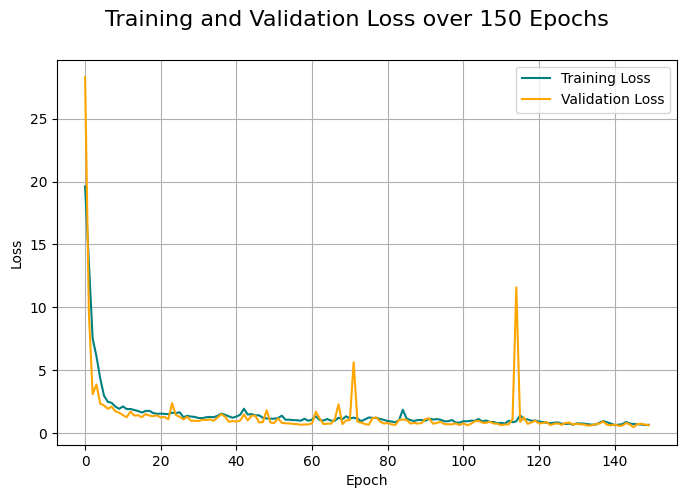

In [6]:
fig = plt.figure(figsize=(8, 5))
plt.plot(hist.history['loss'], color='teal', label='Training Loss')
plt.plot(hist.history['val_loss'], color='orange', label='Validation Loss')
fig.suptitle('Training and Validation Loss over 150 Epochs', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


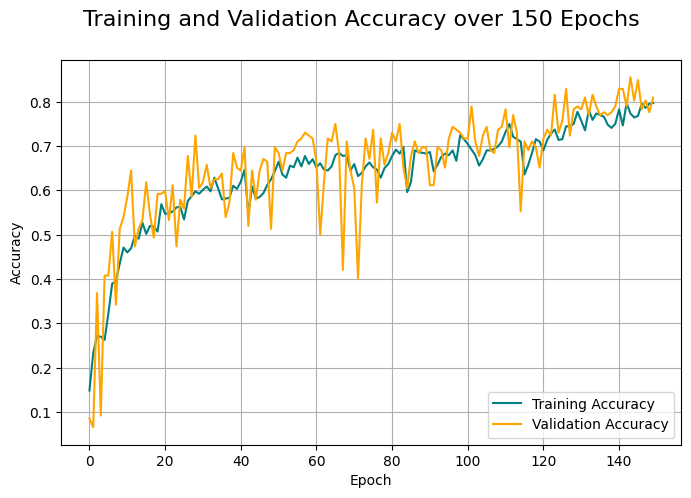

In [7]:
fig = plt.figure(figsize=(8, 5))
plt.plot(hist.history['accuracy'], color='teal', label='Training Accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='Validation Accuracy')
fig.suptitle('Training and Validation Accuracy over 150 Epochs', fontsize=16)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Found 786 files belonging to 22 classes.
Đã phát hiện 22 class: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21']
Tổng cộng: 786 ảnh trong dataset.


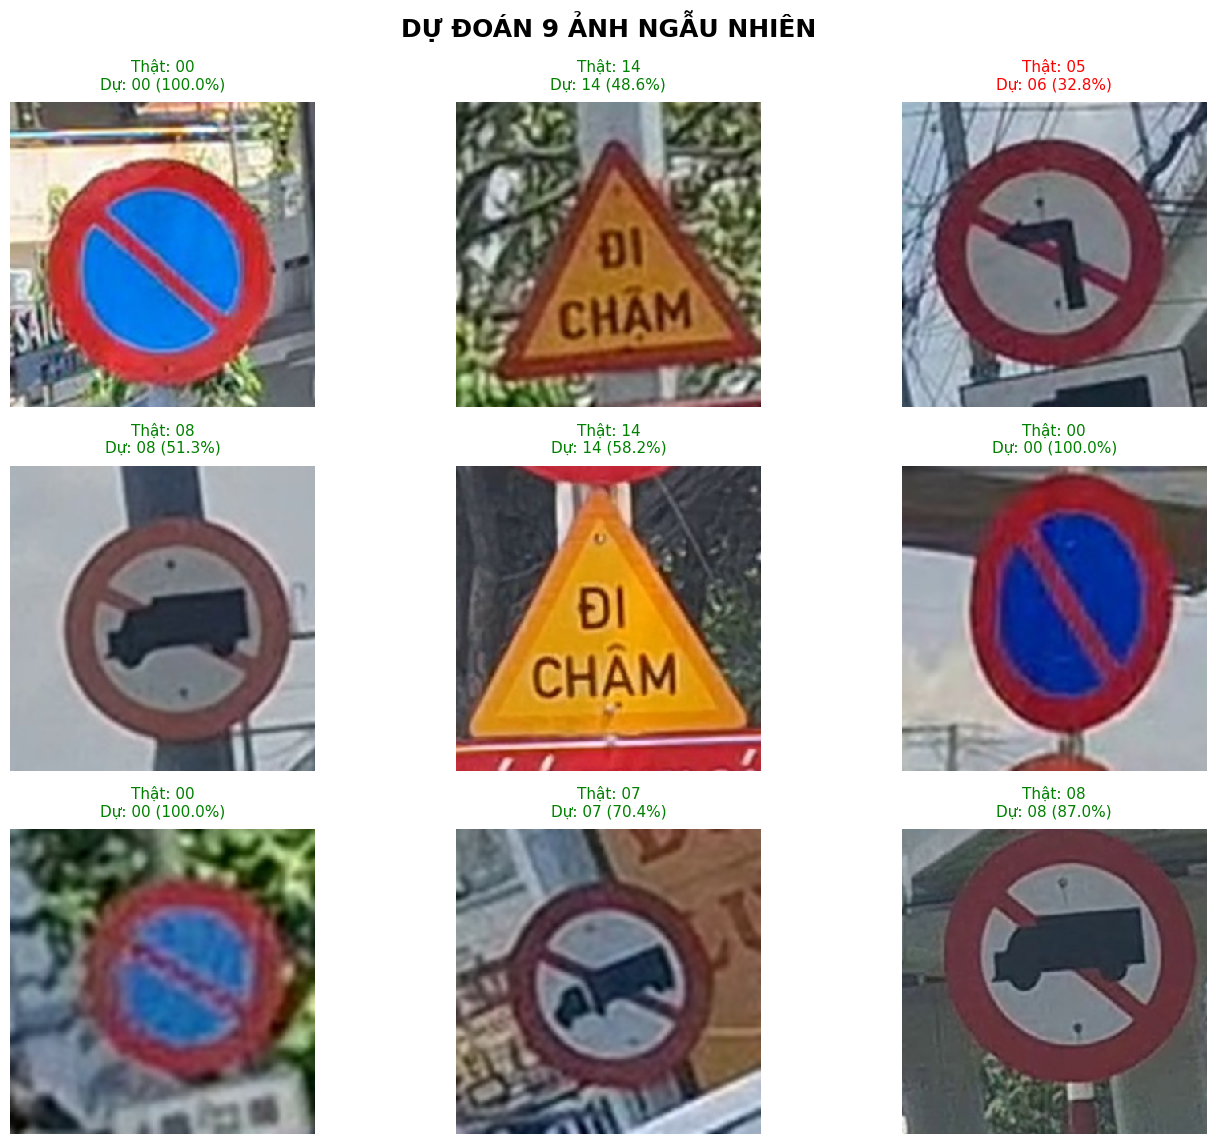

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.preprocessing import image

# -------------------------------
# 1. TẢI DATASET & LẤY class_names TRƯỚC KHI MAP
# -------------------------------
data_dir = 'dataset_sorted'

raw_data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# LẤY class_names NGAY TẠI ĐÂY
class_names = raw_data.class_names
print(f"Đã phát hiện {len(class_names)} class: {class_names}")

# Chuẩn hóa dataset
data = raw_data.map(lambda x, y: (x / 255.0, y))

# -------------------------------
# 2. LẤY TẤT CẢ ĐƯỜNG DẪN ẢNH + NHÃN THẬT
# -------------------------------
all_images = []
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                img_path = os.path.join(class_path, img_name)
                all_images.append((img_path, class_name))

print(f"Tổng cộng: {len(all_images)} ảnh trong dataset.")

# -------------------------------
# 3. CHỌN NGẪU NHIÊN 9 ẢNH (không trùng)
# -------------------------------
random_images = random.sample(all_images, 9)

# -------------------------------
# 4. TẠO LƯỚI 3x3 ĐỂ HIỂN THỊ
# -------------------------------
plt.figure(figsize=(14, 12))  # Tăng kích thước cho rõ

for i, (img_path, true_label) in enumerate(random_images):
    # Load ảnh
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Dự đoán
    pred = model.predict(img_array, verbose=0)
    pred_idx = np.argmax(pred[0])
    pred_label = class_names[pred_idx]
    confidence = pred[0][pred_idx]

    # Vẽ ảnh
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')

    # Màu tiêu đề
    color = 'green' if pred_label == true_label else 'red'

    plt.title(
        f"Thật: {true_label}\n"
        f"Dự: {pred_label} ({confidence:.1%})",
        color=color,
        fontsize=11,
        pad=10
    )

plt.suptitle("DỰ ĐOÁN 9 ẢNH NGẪU NHIÊN", fontsize=18, fontweight='bold', y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
